In [1]:
import pandas as pd

In [3]:
df = pd.read_excel("heart_disease.xlsx")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    str    
 2   cp        908 non-null    str    
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    object 
 6   restecg   908 non-null    str    
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    str    
 11  thal      908 non-null    str    
 12  num       908 non-null    int64  
dtypes: float64(1), int64(5), object(2), str(5)
memory usage: 132.1+ KB


In [5]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


# Exploratory Data Analysis

In [ ]:
# Check Null Values

In [6]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [7]:
df = df.dropna()

In [8]:
import matplotlib.pyplot as plt

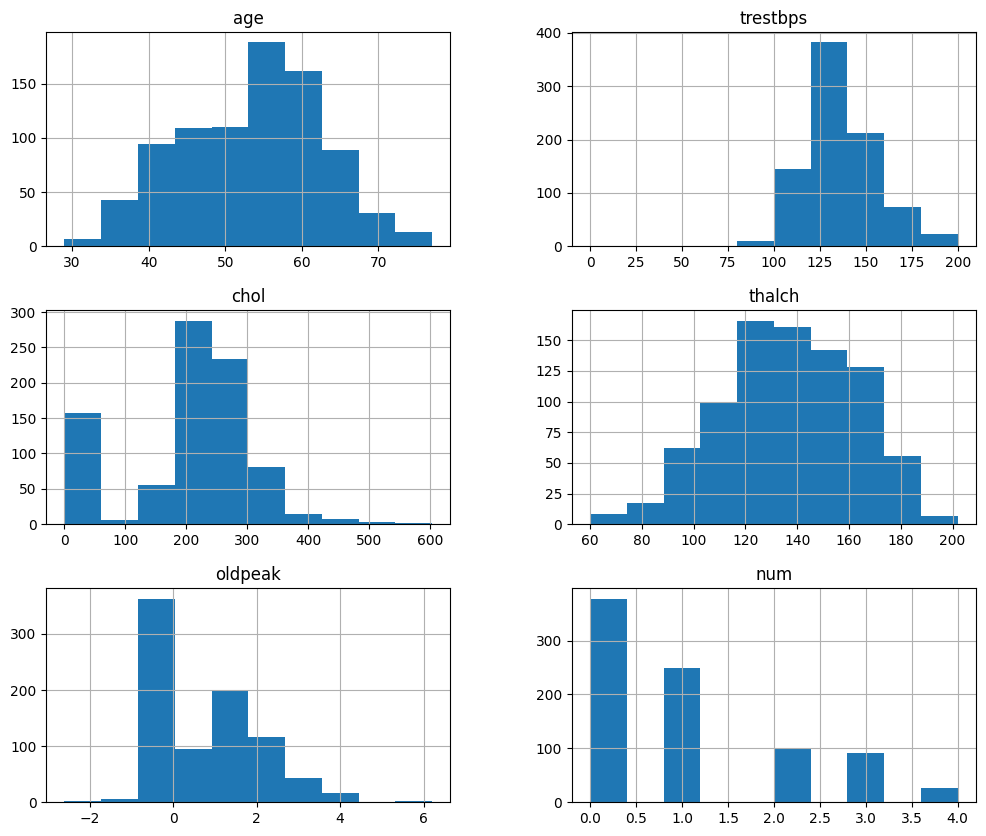

In [9]:
df.hist(figsize=(12,10))
plt.show()

# Correlation Matrix

In [10]:
import seaborn as sns

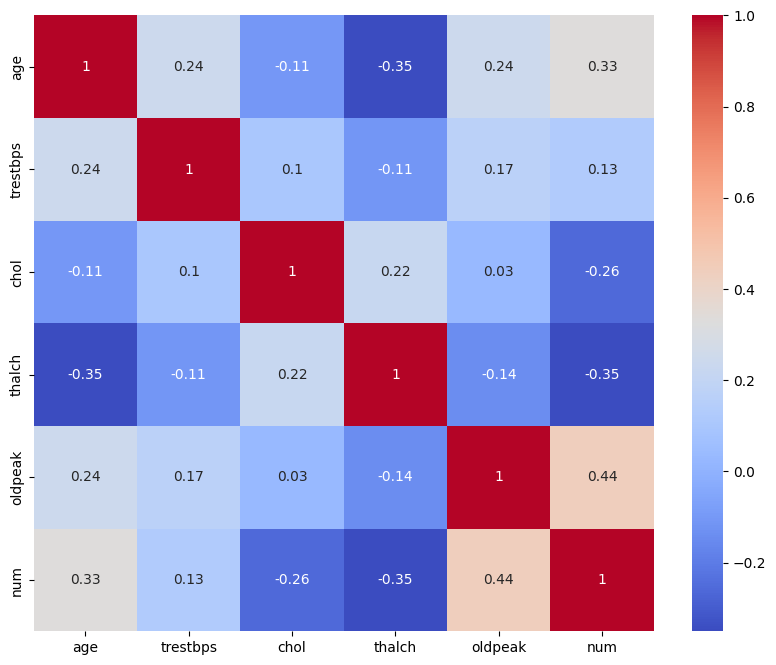

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

# Boxplot for Outliers Detection

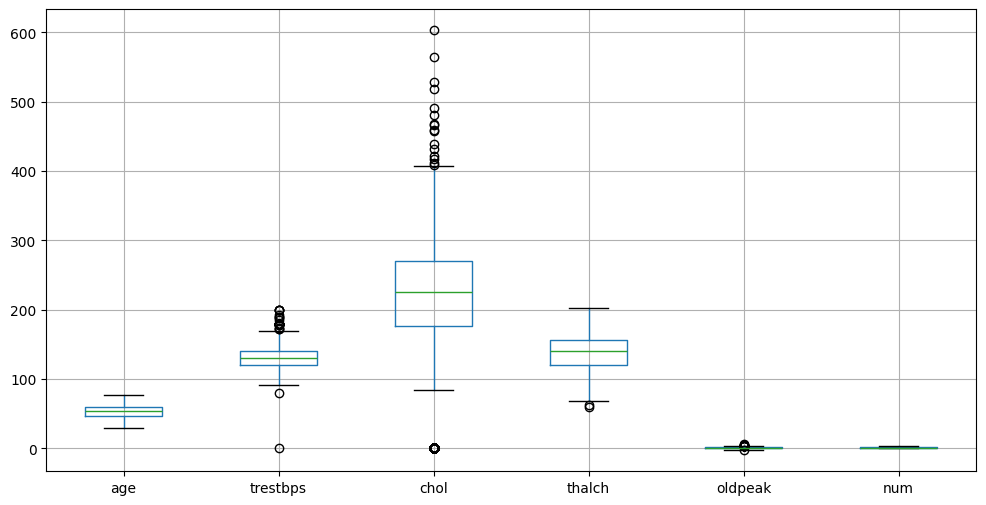

In [12]:
df.boxplot(figsize=(12,6))
plt.show()

# Feature Engineering

In [ ]:
# dataset has categorical columns like sex,cp,thal,slope.

In [ ]:
# Convert categorical to numeric

In [13]:
from sklearn.preprocessing import LabelEncoder

In [16]:
le = LabelEncoder()

for col in df.select_dtypes(include=['object', 'string']):
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

In [17]:
X = df.drop("num", axis=1)
y = df["num"] 

# Decision Tree Classification

In [ ]:
# Train-Test Split

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [ ]:
# Train Model

In [20]:
from sklearn.tree import DecisionTreeClassifier

In [21]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

# Predictions

In [22]:
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score, classification_report

In [24]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5411764705882353
              precision    recall  f1-score   support

           0       0.76      0.75      0.75        80
           1       0.42      0.56      0.48        41
           2       0.21      0.29      0.24        14
           3       0.33      0.19      0.24        27
           4       0.00      0.00      0.00         8

    accuracy                           0.54       170
   macro avg       0.34      0.36      0.34       170
weighted avg       0.53      0.54      0.53       170



# Hyperparameter Tuning

In [25]:
model2 = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=5,
    criterion='entropy',
    random_state=42
)

model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

print("New Accuracy:", accuracy_score(y_test, y_pred2))

New Accuracy: 0.5941176470588235


# Model Visualization

In [26]:
from sklearn.tree import plot_tree

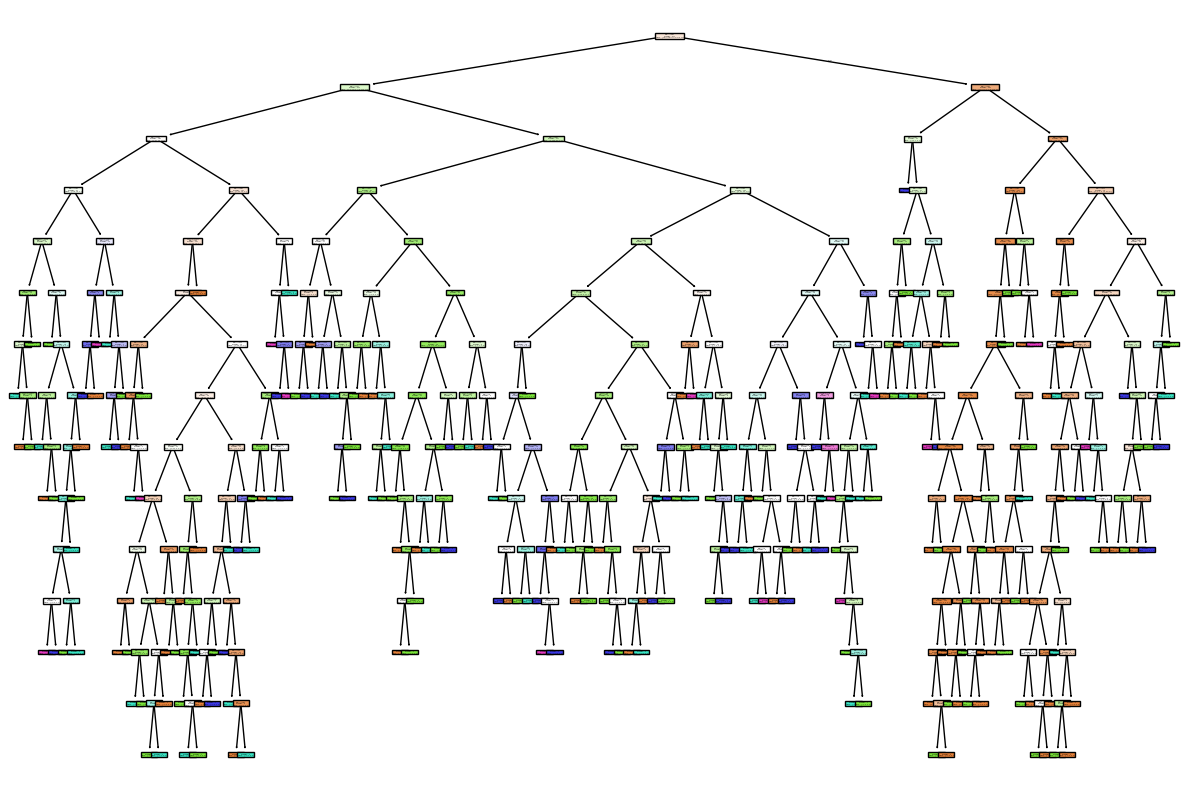

In [28]:
plt.figure(figsize=(15,10))
plot_tree(model, feature_names=X.columns, filled=True)
plt.show()

# Feature Importance

In [29]:
import pandas as pd

In [31]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

print(importance.sort_values(by='Importance', ascending=False))

     Feature  Importance
4       chol    0.174263
0        age    0.139887
2         cp    0.137919
7     thalch    0.131045
3   trestbps    0.113828
9    oldpeak    0.102352
11      thal    0.047035
10     slope    0.046922
6    restecg    0.032730
1        sex    0.027679
8      exang    0.024744
5        fbs    0.021597


In [ ]:
# Most Important Features
chol (Cholesterol) → Highest importance (0.174)
age → Strong influence
cp (Chest Pain Type) → Very important
thalch (Max Heart Rate) → Significant factor
trestbps (Resting Blood Pressure) → Moderate impact
oldpeak → Also contributes

# Interview Questions

In [ ]:
#1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?
These are hyperparameters of decision tree models-
-max_depth which Controls tree height
Small means underfitting
Large means overfitting
- min_samples_split
Minimum samples required to split
Higher value means simpler tree
 -criterion Measures split quality
gini (default)
entropy (information gain)

In [ ]:
# 2. What is the difference between the Label encoding and One-hot encoding?
The primary difference between Label encoding and One-hot encoding is how they represent categorical data numerically. 
Label encoding uses a single column of integers, whereas One-hot encoding creates multiple binary columns.
Label Encoding Converts categories into numbers
Example:
Male = 0, Female = 1
One-Hot Encoding Creates separate columns
Example:
Gender_Male	Gender_Female
1	0
0	1

# Final Conclusion

In [ ]:
#Decision Tree model was successfully implemented.
Data was preprocessed and categorical variables were encoded.
Model performance was evaluated using accuracy and classification report.
Hyperparameter tuning improved model performance.
Feature importance helped identify key factors affecting heart disease.